In [1]:
import pandas as pd
import configparser
import pylab as pl

In [2]:
# Read the CSV file with proper encoding and parse the timestamps
data = pd.read_csv('Example_UIT.csv',encoding='ISO-8859-1',delimiter = ';', 
                   parse_dates=['Timestamp'], dayfirst=True)

In [3]:
# Set the timestamp column as the DataFrame index
data.set_index('Timestamp', inplace=True)
# Ensure the index is in datetime format
data.index = pd.to_datetime(data.index)

In [5]:
temperature = data['2T4 [°C]']
#timestamp = data['Timestamp']

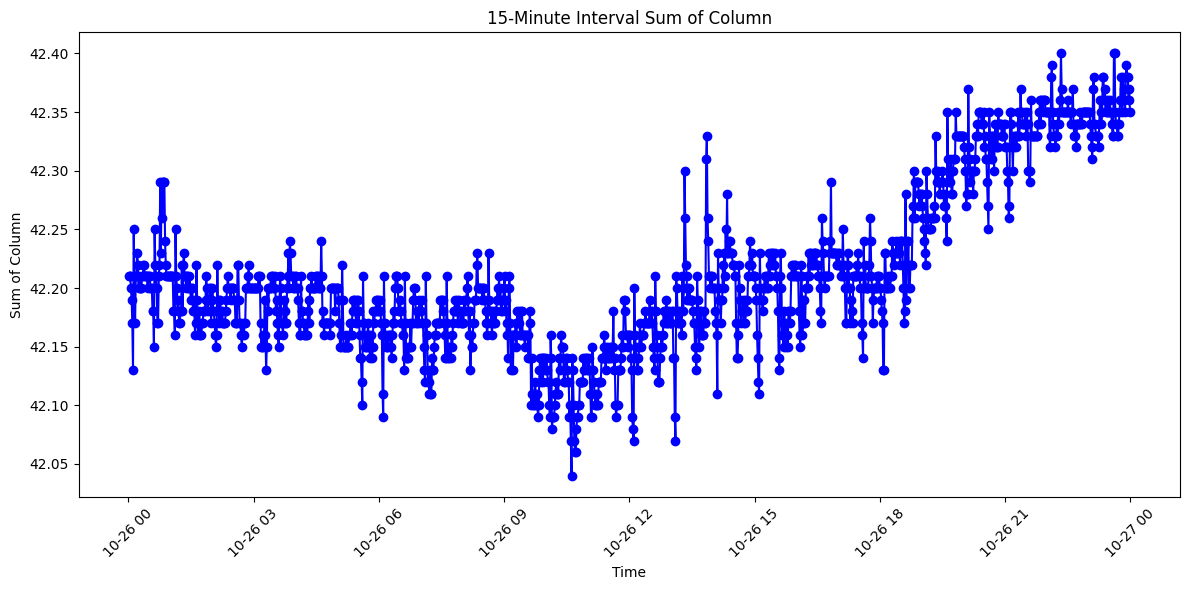

In [6]:
import matplotlib.pyplot as plt

# Plot the resampled data
plt.figure(figsize=(12, 6))
plt.plot(data['2T4 [°C]'].index, data['2T1 [°C]'].values, marker='o', linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Sum of Column')
plt.title('15-Minute Interval Sum of Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Resample the data in 15-minute intervals and calculate the sum of a column
resampled_data = data['2T1 [°C]'].resample('15T').mean()

In [29]:
# Calculate the moving average with a window
window_size = 15 #Hourly moving average
moving_average = data['2T1 [°C]'].rolling(window=window_size).mean()

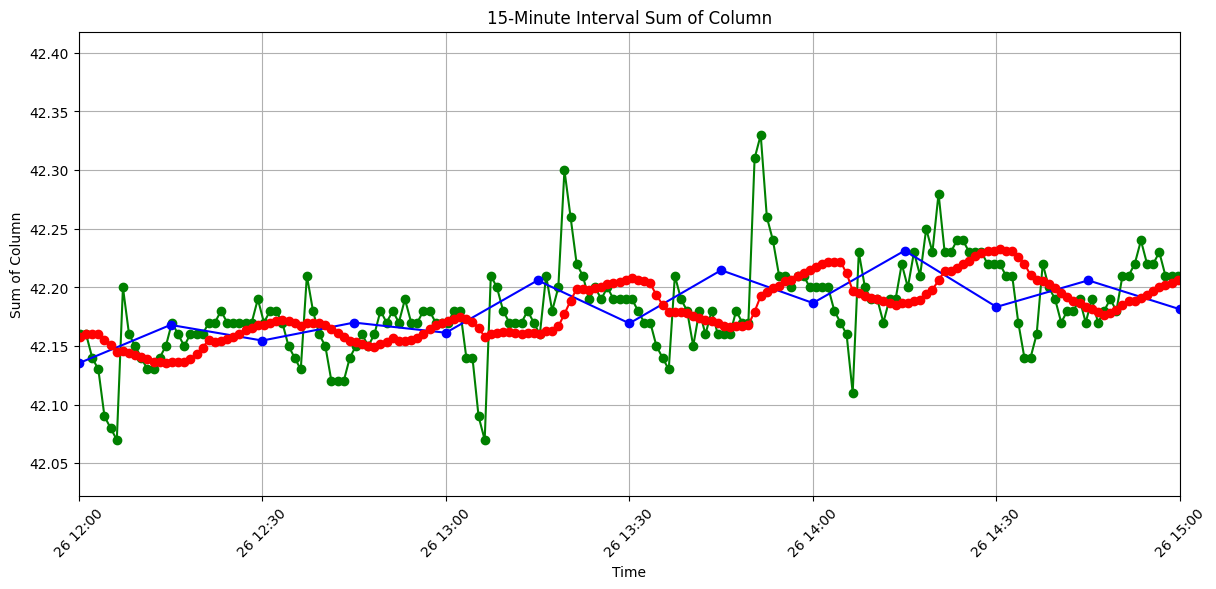

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Plot the resampled data
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['2T1 [°C]'], marker='o', linestyle='-', color='g')
plt.plot(resampled_data.index, resampled_data.values, marker='o', linestyle='-', color='b')
plt.plot(moving_average.index, moving_average.values, marker='o', linestyle='-', color='r')
plt.xlabel('Time')
plt.ylabel('Sum of Column')
plt.title('15-Minute Interval Sum of Column')
plt.xticks(rotation=45)
plt.tight_layout()
# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
start_time = datetime(2023, 10, 26, 12, 0)
end_time = datetime(2023, 10, 26, 15, 0)
plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
#ax.set_ylim([42, 42.2])
plt.grid()
plt.show()

In [27]:
# Assuming 'resampled_data' is your DataFrame with datetime index and a column to search for the specific value
value_to_find =  42.07 # The value you want to search for

# Filter the DataFrame to find rows where the specified column has the desired value
filtered_data = data[data['2T1 [°C]'] == value_to_find]

# Check if there are any rows with the specified value
if not filtered_data.empty:
    # Get the timestamp associated with the specific value
    time_associated_with_value = filtered_data.index[0]
    print(f"The time associated with the value {value_to_find} is: {time_associated_with_value}")
else:
    print(f"No data with the value {value_to_find} found.")

The time associated with the value 42.07 is: 2023-10-26 10:35:59


In [ ]:
import matplotlib.pyplot as plt

# Manipulate time series data (for example, group by date and calculate the sum of a column)
daily_data = data.groupby(data['Timestamp'].dt.date)['2T4 [°C]'].sum()

# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(daily_data.index, daily_data.values, marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Sum of Column')
plt.title('Daily Sum of Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
timestamp =pd.to_datetime(timestamp)

In [ ]:
pl.plot(timestamp,temperature)

In [15]:
# Modify the .ini file as before
import configparser

config = configparser.ConfigParser()
config.read('Parameter_2023-10-09_16-14-06.ini')

#config.set('[REACTOR 1]', 'MessageGasflowHigh', str(total_sum))
ciao = resampled_data.values[0]
config.set('REACTOR1', 'MessageGasflowHigh', str(ciao))

with open('Parameter_2023-10-09_16-14-06.ini', 'w') as config_file:
    config.write(config_file)